In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder # Поки імпортуємо, використаємо пізніше

try:
    df = pd.read_csv('Student_Performance.csv')
    print("Датасет успішно завантажено.")
except FileNotFoundError:
    print("ПОМИЛКА: Файл 'Student Performance.csv' не знайдено.")
    print("Будь ласка, завантаж його або перевір шлях.")

Датасет успішно завантажено.


In [19]:
# 2. Початковий розвідковий аналіз (EDA)
print("\n--- df.info() ---")
df.info()


--- df.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [20]:
print("\n--- df.describe() ---")
print(df.describe())



--- df.describe() ---
       Hours Studied  Previous Scores   Sleep Hours  \
count   10000.000000     10000.000000  10000.000000   
mean        4.992900        69.445700      6.530600   
std         2.589309        17.343152      1.695863   
min         1.000000        40.000000      4.000000   
25%         3.000000        54.000000      5.000000   
50%         5.000000        69.000000      7.000000   
75%         7.000000        85.000000      8.000000   
max         9.000000        99.000000      9.000000   

       Sample Question Papers Practiced  Performance Index  
count                      10000.000000       10000.000000  
mean                           4.583300          55.224800  
std                            2.867348          19.212558  
min                            0.000000          10.000000  
25%                            2.000000          40.000000  
50%                            5.000000          55.000000  
75%                            7.000000          71.00

In [21]:
print("\n--- Пропущені значення (df.isnull().sum()) ---")
print(df.isnull().sum())


--- Пропущені значення (df.isnull().sum()) ---
Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64



--- Унікальні значення в 'Extracurricular Activities' до обробки ---
['Yes' 'No']

--- Унікальні значення після обробки ---
[1 0]

--- Типи даних після обробки ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  int64  
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 468.9 KB

--- Побудова теплової карти кореляцій ---


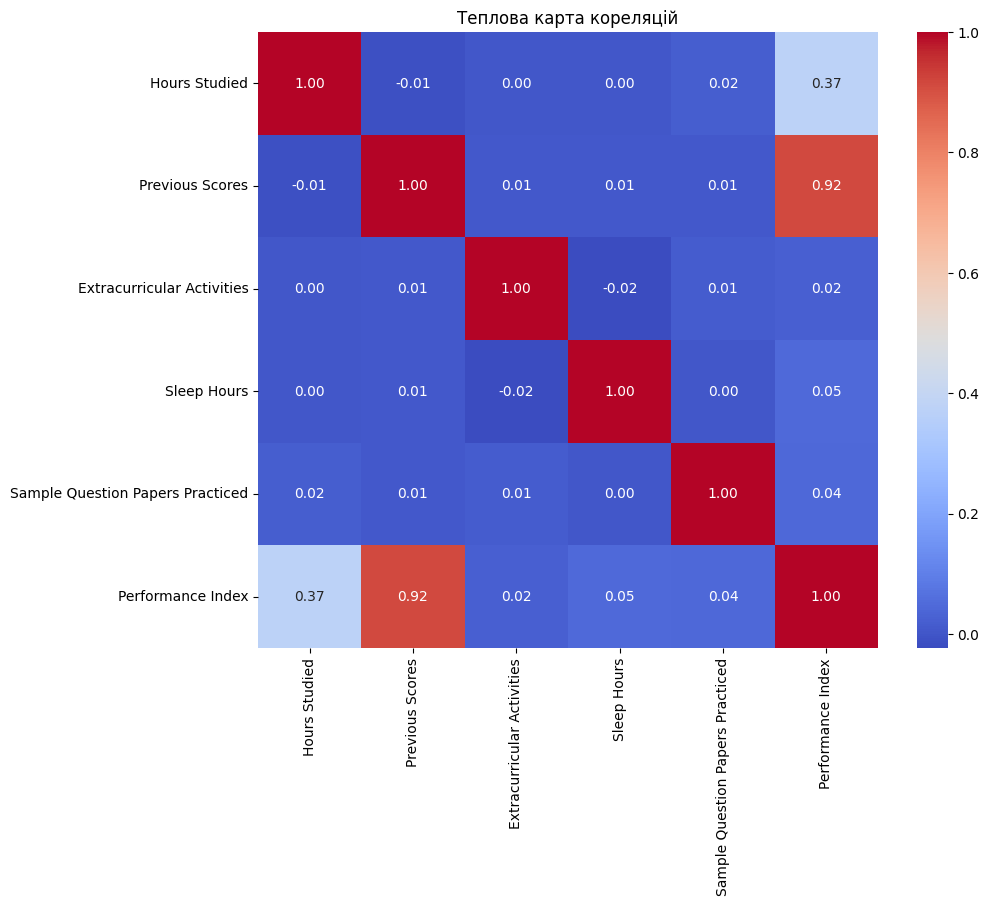

Графік 'Теплова карта кореляцій' має відкритися в окремому вікні.


In [22]:

# 3. Обробка категоріальної змінної 'Extracurricular Activities'
print("\n--- Унікальні значення в 'Extracurricular Activities' до обробки ---")
print(df['Extracurricular Activities'].unique())

# Замінюємо 'Yes' на 1 і 'No' на 0
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})

print("\n--- Унікальні значення після обробки ---")
print(df['Extracurricular Activities'].unique())
print("\n--- Типи даних після обробки ---")
df.info() # Перевіримо, що Dtype змінився

# 4. EDA - Теплова карта кореляцій (для всіх чисельних змінних)
print("\n--- Побудова теплової карти кореляцій ---")

plt.figure(figsize=(10, 8))
# Тепер .corr() спрацює коректно, бо всі стовпці чисельні
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Теплова карта кореляцій')
plt.show()

print("Графік 'Теплова карта кореляцій' має відкритися в окремому вікні.")

In [23]:

# 5. Вибір ознак та цільової змінної
# Ціль (y) - те, що ми прогнозуємо
y = df['Performance Index']
# Ознаки (X) - все, окрім нашої цілі
X = df.drop('Performance Index', axis=1)

print("\n--- Ознаки (X) ---")
print(X.head())
print("\n--- Ціль (y) ---")
print(y.head())

# 6. Поділ на навчальну та тестову вибірки
# Використовуємо параметри з інструкції: test_size=0.2, random_state=42 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\n--- Розміри вибірок ---")
print(f"Розмір X_train: {X_train.shape}")
print(f"Розмір X_test: {X_test.shape}")
print(f"Розмір y_train: {y_train.shape}")
print(f"Розмір y_test: {y_test.shape}")


--- Ознаки (X) ---
   Hours Studied  Previous Scores  Extracurricular Activities  Sleep Hours  \
0              7               99                           1            9   
1              4               82                           0            4   
2              8               51                           1            7   
3              5               52                           1            5   
4              7               75                           0            8   

   Sample Question Papers Practiced  
0                                 1  
1                                 2  
2                                 2  
3                                 2  
4                                 5  

--- Ціль (y) ---
0    91.0
1    65.0
2    45.0
3    36.0
4    66.0
Name: Performance Index, dtype: float64

--- Розміри вибірок ---
Розмір X_train: (8000, 5)
Розмір X_test: (2000, 5)
Розмір y_train: (8000,)
Розмір y_test: (2000,)


In [24]:

# 7. Нормалізація/Стандартизація
print("\n--- Масштабування даних ---")

# Створюємо StandardScaler
scaler = StandardScaler()

# Навчаємо (fit) скалер ТІЛЬКИ на навчальних даних
# і одразу трансформуємо (transform) їх
X_train_scaled = scaler.fit_transform(X_train)

# Трансформуємо (transform) тестові дані,
# використовуючи середнє та відхилення з навчальних даних
X_test_scaled = scaler.transform(X_test)

print("Дані успішно відмасштабовано.")
print(f"Середнє значення 1-ї ознаки (X_train_scaled): {X_train_scaled[:, 0].mean():.2f}")
print(f"Відхилення 1-ї ознаки (X_train_scaled): {X_train_scaled[:, 0].std():.2f}")


# 8. Додаємо стовпчик одиниць для intercept (β_0)
# np.c_ додає стовпчик зліва
X_train_final = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_test_final = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]

print("\n--- Додано стовпчик intercept ---")
print("Розмір X_train_final:", X_train_final.shape)
print("Розмір X_test_final:", X_test_final.shape)

print("\n--- Перший рядок X_train_final (приклад) ---")
print(X_train_final[0])


--- Масштабування даних ---
Дані успішно відмасштабовано.
Середнє значення 1-ї ознаки (X_train_scaled): 0.00
Відхилення 1-ї ознаки (X_train_scaled): 1.00

--- Додано стовпчик intercept ---
Розмір X_train_final: (8000, 6)
Розмір X_test_final: (2000, 6)

--- Перший рядок X_train_final (приклад) ---
[ 1.          0.00645547 -1.18384439 -0.98930717  0.26988848  0.13404112]


In [25]:

# 1. Функція для обчислення функції втрат (MSE)
def compute_cost(X, y, b):
    m = len(y) # Кількість зразків
    predictions = X.dot(b) # Прогноз: y_hat = X * b
    errors = predictions - y # Помилки
    mse = (1 / m) * np.sum(errors**2) # Формула MSE
    return mse

# 2. Функція градієнтного спуску
def gradient_descent(X, y, b, learning_rate, epochs):
    m = len(y)
    cost_history = np.zeros(epochs) # Масив для запису MSE на кожній епосі

    for i in range(epochs): # Цикл навчання
        # 1. Обчислення передбачень (y_hat)
        predictions = X.dot(b)
        
        # 2. Обчислення помилки
        errors = predictions - y
        
        # 3. Обчислення градієнта (похідна MSE за b)
        # Формула: gradient = (2/m) * X.T * errors
        gradient = (2 / m) * X.T.dot(errors)
        
        # 4. Оновлення ваг
        b = b - learning_rate * gradient
        
        # 5. Збереження поточного MSE для історії
        cost_history[i] = compute_cost(X, y, b)
    
    return b, cost_history # Повертаємо фінальні ваги та історію навчання

# 3. Ініціалізація параметрів та гіперпараметрів
# Ініціалізуємо вектор ваг b нулями
# Кількість ваг = кількість стовпців у X_train_final (6)
b_initial = np.zeros(X_train_final.shape[1])

# Гіперпараметри з інструкції
epochs = 1000
learning_rate = 0.01

print("\n--- Початок навчання моделі ---")
print(f"Гіперпараметри: epochs={epochs}, learning_rate={learning_rate}")

# 4. Навчання моделі!
# Викликаємо нашу функцію на навчальних даних
b_final, cost_history = gradient_descent(X_train_final, y_train, b_initial, learning_rate, epochs)

print("\n--- Навчання завершено ---")
print("Фінальні коефіцієнти (b_final):")
print(b_final)

print(f"\nПочаткова помилка (MSE): {cost_history[0]:.4f}")
print(f"Фінальна помилка (MSE): {cost_history[-1]:.4f}")


--- Початок навчання моделі ---
Гіперпараметри: epochs=1000, learning_rate=0.01

--- Навчання завершено ---
Фінальні коефіцієнти (b_final):
[55.31149991  7.40134077 17.63727123  0.30429076  0.81003107  0.54884172]

Початкова помилка (MSE): 3292.5390
Фінальна помилка (MSE): 4.1697



--- Побудова графіка збіжності MSE ---


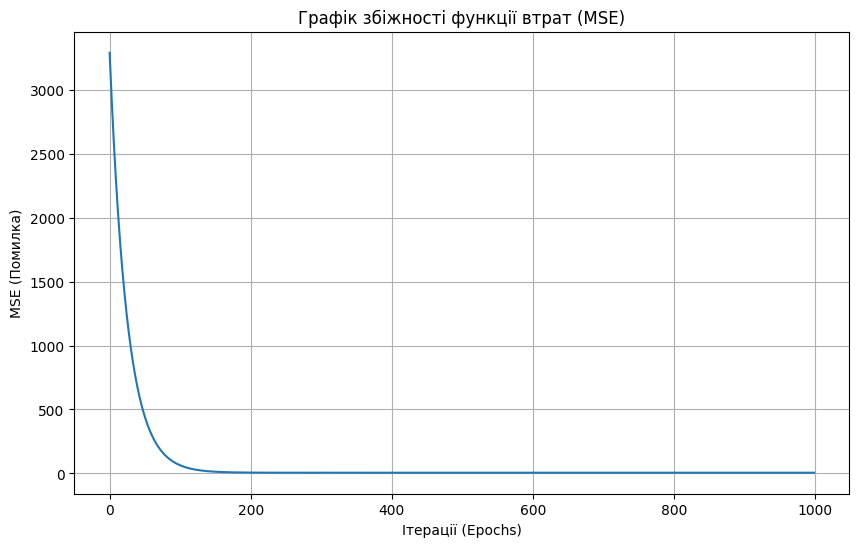

Графік 'збіжності' має відкритися в окремому вікні.


In [26]:
# 5. Візуалізація навчання (графік cost_history)
print("\n--- Побудова графіка збіжності MSE ---")
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), cost_history)
plt.title('Графік збіжності функції втрат (MSE)')
plt.xlabel('Ітерації (Epochs)')
plt.ylabel('MSE (Помилка)')
plt.grid(True)
plt.show()
print("Графік 'збіжності' має відкритися в окремому вікні.")

In [27]:

# 1. Прогнозування на тестових даних
# y_pred = X_test_final * b_final
y_pred = X_test_final.dot(b_final)

# 2. Розрахунок метрик
print("\n--- Оцінка на тестових даних ---")

# MSE (Mean Squared Error)
# (y_test - y_pred)**2 -- це квадрат помилки для кожного зразка
# np.mean(...) -- бере середнє значення
mse_test = np.mean((y_pred - y_test)**2)
print(f"MSE на тестовій вибірці: {mse_test:.4f}")

# R^2 Score (Коефіцієнт детермінації)
# Це "загальна дисперсія" (наскільки y_test відрізняється від свого середнього)
total_variance = np.sum((y_test - np.mean(y_test))**2)
# Це "залишкова дисперсія" (скільки помилок залишилось після роботи моделі)
residual_variance = np.sum((y_pred - y_test)**2)

# R^2 = 1 - (помилки моделі / загальна дисперсія)
r2 = 1 - (residual_variance / total_variance)
print(f"R^2 Score на тестовій вибірці: {r2:.4f}")


--- Оцінка на тестових даних ---
MSE на тестовій вибірці: 4.0826
R^2 Score на тестовій вибірці: 0.9890



--- Етап 5: Перевірка припущень ---
Побудова графіка 'Залишки vs. Передбачені значення'...


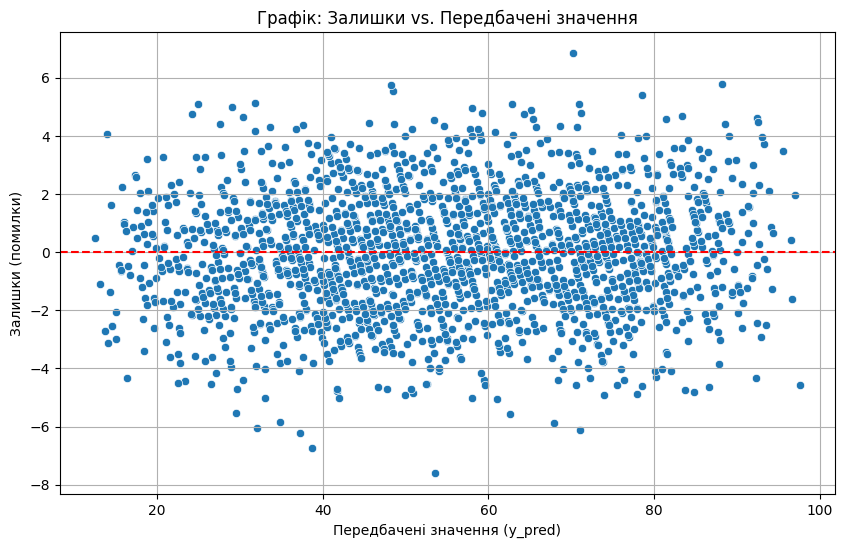

Графік 'Залишки vs. Передбачені' має відкритися.


In [28]:

print("\n--- Етап 5: Перевірка припущень ---")

# Розраховуємо залишки (помилки) на тестовій вибірці
residuals = y_test - y_pred

# 1. Перевірка Лінійності (Припущення 1)
# 2. Перевірка Гомоскедастичності (Припущення 4)
print("Побудова графіка 'Залишки vs. Передбачені значення'...")

plt.figure(figsize=(10, 6))
# y_pred - по осі X, residuals - по осі Y
sns.scatterplot(x=y_pred, y=residuals)
# Додаємо горизонтальну лінію на рівні 0, щоб краще бачити патерни
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Графік: Залишки vs. Передбачені значення')
plt.xlabel('Передбачені значення (y_pred)')
plt.ylabel('Залишки (помилки)')
plt.grid(True)
plt.show()

print("Графік 'Залишки vs. Передбачені' має відкритися.")

Перевірка 1: Лінійність та Перевірка 4: Гомоскедастичність

Для одночасної перевірки цих двох припущень був побудований графік залежності залишків (residuals) від передбачених значень (predicted values).

1. Аналіз на лінійність (Припущення 1)

    Очікування: Залишки мають бути випадково розсіяні навколо горизонтальної лінії y=0. 

Результат: На графіку точки розсіюються хаотично, без будь-якого чіткого систематичного патерну (наприклад, U-подібної кривої чи параболи).

    Висновок: Це свідчить про те, що модель коректно враховує лінійний зв'язок у даних. Припущення про лінійність виконується.

2. Аналіз на гомоскедастичність (Припущення 4)

    Очікування: Дисперсія залишків має бути постійною для всіх рівнів передбачених значень. "Хмара" точок повинна мати приблизно однакову ширину.

Результат: Графік демонструє, що вертикальний розкид ("ширина хмари") залишків є сталим по всьому діапазону передбачених значень. Ми не спостерігаємо "воронкоподібного" патерну (гетероскедастичності).

Висновок: Дисперсія помилок є постійною. Припущення про гомоскедастичність виконується.


--- Перевірка 3: Нормальність залишків ---
Побудова Q-Q plot...


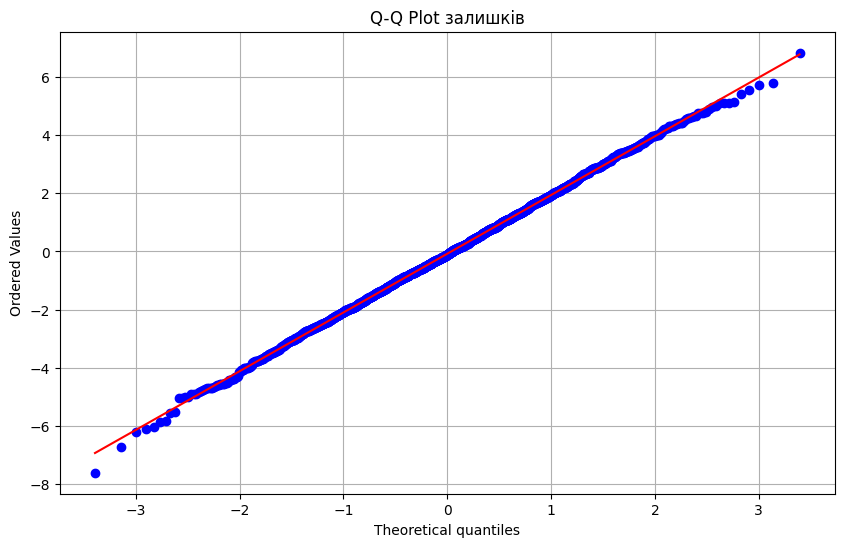

Q-Q plot має відкритися в окремому вікні.
Проведення тесту Шапіро-Вілка...
Статистика тесту Шапіро-Вілка: 0.9996
P-value тесту Шапіро-Вілка: 0.9751
Висновок: P-value > 0.05, отже, залишки розподілені нормально.


In [29]:
import scipy.stats as stats

# 3. Перевірка Нормальності залишків (Припущення 3)
print("\n--- Перевірка 3: Нормальність залишків ---")

# Метод 1: Q-Q plot
print("Побудова Q-Q plot...")
plt.figure(figsize=(10, 6))
# 'residuals' - це наші помилки (y_test - y_pred)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot залишків')
plt.grid(True)
plt.show()
print("Q-Q plot має відкритися в окремому вікні.")

# Метод 2: Статистичний тест (Shapiro-Wilk)
# Беремо H0: "Залишки розподілені нормально"
# Якщо p-value > 0.05, ми приймаємо H0.
print("Проведення тесту Шапіро-Вілка...")
# Тест може бути повільним на >5000 зразках,
# але на наших 2000 (розмір y_test) він спрацює швидко.
shapiro_stat, shapiro_p_value = stats.shapiro(residuals)

print(f"Статистика тесту Шапіро-Вілка: {shapiro_stat:.4f}")
print(f"P-value тесту Шапіро-Вілка: {shapiro_p_value:.4f}")

if shapiro_p_value > 0.05:
    print("Висновок: P-value > 0.05, отже, залишки розподілені нормально.")
else:
    print("Висновок: P-value <= 0.05, отже, залишки НЕ розподілені нормально.")

Перевірка 3: Нормальність залишків

Для перевірки припущення про нормальний розподіл залишків було використано два методи: візуальний (Q-Q plot) та статистичний (тест Шапіро-Вілка).

1. Q-Q Plot (Графік Квантиль-Квантиль)

    Очікування: Якщо залишки розподілені нормально, точки на графіку повинні лягти якомога ближче до прямої діагональної лінії (теоретичні квантилі vs. впорядковані залишки).

    Результат: Як видно з наданого графіка, точки даних (сині кола) практично ідеально лягають на червону лінію. Спостерігаються лише незначні відхилення на самих "хвостах" (краях) розподілу, що є абсолютно нормальним.

    Висновок: Візуальний аналіз Q-Q plot дає вагомі підстави вважати, що залишки розподілені нормально.

2. Тест Шапіро-Вілка

    Очікування: Це статистичний тест, що перевіряє нульову гіпотезу (H0) про те, що дані (в нашому випадку — залишки) взяті з нормально розподіленої сукупності. Ми шукаємо p-value > 0.05, щоб прийняти цю гіпотезу.

    Результат:

        Статистика тесту Шапіро-Вілка: 0.9996

        P-value тесту Шапіро-Вілка: 0.9751

    Висновок: Отримане значення p-value (0.9751) є значно більшим за рівень значущості 0.05. Це означає, що у нас немає підстав відхиляти нульову гіпотезу.

Загальний висновок: Обидва методи підтверджують, що залишки моделі мають нормальний розподіл. Припущення про нормальність залишків виконується.

In [30]:
import statsmodels.api as sm # Імпортуємо головну бібліотеку
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 2. Перевірка Відсутності мультиколінеарності (Припущення 2)
print("\n--- Перевірка 2: Відсутність мультиколінеарності (VIF) - Виправлений розрахунок ---")

X_train_with_const = sm.add_constant(X_train)

# Створюємо DataFrame для VIF
vif_data = pd.DataFrame()
# Тепер беремо назви стовпців з нового DataFrame
vif_data["feature"] = X_train_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_with_const.values, i) for i in range(len(X_train_with_const.columns))]

print("--- VIF (включаючи константу) ---")
print(vif_data)

# Відфільтруємо VIF для самої константи, він нам не потрібен для аналізу
vif_data_filtered = vif_data[vif_data["feature"] != "const"]
print("\n--- VIF (тільки для ознак) ---")
print(vif_data_filtered)

print("\nВисновок щодо VIF:")
if all(vif_data_filtered["VIF"] < 5):
    print("Всі значення VIF < 5. Мультиколінеарність відсутня.")
else:
    print("Виявлено потенційну мультиколінеарність (VIF >= 5).")


--- Перевірка 2: Відсутність мультиколінеарності (VIF) - Виправлений розрахунок ---
--- VIF (включаючи константу) ---
                            feature        VIF
0                             const  39.149899
1                     Hours Studied   1.000387
2                   Previous Scores   1.000243
3        Extracurricular Activities   1.000428
4                       Sleep Hours   1.000461
5  Sample Question Papers Practiced   1.000320

--- VIF (тільки для ознак) ---
                            feature       VIF
1                     Hours Studied  1.000387
2                   Previous Scores  1.000243
3        Extracurricular Activities  1.000428
4                       Sleep Hours  1.000461
5  Sample Question Papers Practiced  1.000320

Висновок щодо VIF:
Всі значення VIF < 5. Мультиколінеарність відсутня.


Перевірка 2: Відсутність мультиколінеарності

Для перевірки цього припущення був розрахований VIF (Variance Inflation Factor) для кожної ознаки-предиктора.

    Очікування: VIF показує, наскільки сильно одна ознака лінійно пов'язана з іншими. Значення VIF < 5 вважається нормою (відсутність мультиколінеарності). Ідеальне значення – 1.0.

    Результат: Розраховані значення VIF для всіх ознак:

        Hours Studied: 1.000387

        Previous Scores: 1.000243

        Extracurricular Activities: 1.000428

        Sleep Hours: 1.000461

        Sample Question Papers Practiced: 1.000320

    Висновок: Всі значення VIF практично дорівнюють 1.0, що є ідеальним випадком. Це повністю підтверджує висновки з теплової карти кореляцій. Припущення про відсутність мультиколінеарності виконується.

In [31]:
from statsmodels.stats.stattools import durbin_watson

# 5. Перевірка Відсутності автокореляції (Припущення 5)
print("\n--- Перевірка 5: Відсутність автокореляції (Тест Дарбіна-Вотсона) ---")

# Тест проводиться на залишках (residuals) з тестової вибірки
dw_statistic = durbin_watson(residuals)

print(f"Статистика Дарбіна-Вотсона: {dw_statistic:.4f}")

if 1.5 < dw_statistic < 2.5:
    print("Висновок: Значення близьке до 2.0, автокореляція відсутня.")
else:
    print("Висновок: Значення далеке від 2.0, можлива автокореляція.")


--- Перевірка 5: Відсутність автокореляції (Тест Дарбіна-Вотсона) ---
Статистика Дарбіна-Вотсона: 2.0472
Висновок: Значення близьке до 2.0, автокореляція відсутня.


Перевірка 5: Відсутність автокореляції залишків

Це припущення перевіряє, чи не корелюють залишки (помилки) моделі самі з собою, що особливо важливо для часових рядів.

    Очікування: Для перевірки використовується тест Дарбіна-Вотсона. Значення статистики (d) повинно бути близьким до 2.0. Значення в діапазоні (1.5, 2.5) вказують на відсутність автокореляції.

    Результат:

        Статистика Дарбіна-Вотсона: 2.0472

    Висновок: Отримане значення 2.0472 знаходиться в ідеальному діапазоні. Припущення про відсутність автокореляції виконується.


--- Перевірка 6: Викиди та Впливові спостереження ---
Кількість спостережень (n): 8000
Поріг для відстані Кука (4/n): 0.000500
Знайдено впливових точок (D > 4/n): 391


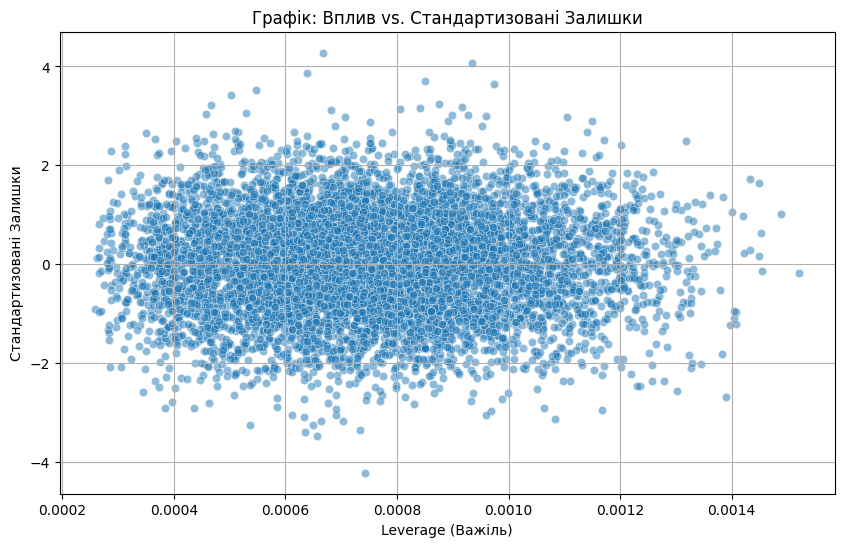

Графік 'Вплив vs. Залишки' має відкритися.


In [32]:
# ... (твій попередній код з Durbin-Watson) ...
import statsmodels.api as sm # Ми вже імпортували його для VIF

# 6. Перевірка Викидів та Впливових спостережень (Припущення 6)
print("\n--- Перевірка 6: Викиди та Впливові спостереження ---")

# Для отримання діагностики (як Відстань Кука), ми створимо
# модель OLS з statsmodels на НАВЧАЛЬНИХ даних,
# оскільки саме вони впливали на коефіцієнти.
# X_train_with_const - це X_train з доданою константою (з кроку VIF)
model_sm = sm.OLS(y_train, X_train_with_const).fit()

# Отримуємо об'єкт впливу
influence = model_sm.get_influence()

# 1. Отримуємо відстань Кука для кожної точки
cooks_d = influence.cooks_distance[0]

# 2. Визначаємо поріг (threshold) за формулою 4/n 
n = len(y_train)
cooks_threshold = 4 / n

print(f"Кількість спостережень (n): {n}")
print(f"Поріг для відстані Кука (4/n): {cooks_threshold:.6f}")

# 3. Знаходимо кількість впливових точок
influential_points_count = np.sum(cooks_d > cooks_threshold)

print(f"Знайдено впливових точок (D > 4/n): {influential_points_count}")

# 4. Візуалізація (Графік Leverage vs. Standardized Residuals)
# Це стандартний графік для пошуку впливових точок
leverage = influence.hat_matrix_diag
std_residuals = influence.resid_studentized_internal

plt.figure(figsize=(10, 6))
sns.scatterplot(x=leverage, y=std_residuals, alpha=0.5)
plt.title('Графік: Вплив vs. Стандартизовані Залишки')
plt.xlabel('Leverage (Важіль)')
plt.ylabel('Стандартизовані Залишки')
plt.grid(True)
plt.show()

print("Графік 'Вплив vs. Залишки' має відкритися.")

1. Аналіз за Відстанню Кука (Cook's Distance)

    Очікування: Впливовими вважаються точки, відстань Кука (D) яких перевищує поріг, що розраховується за формулою 4/n.

    Результат:

        Кількість спостережень (n): 8000

        Поріг для відстані Кука (4/n): 0.000500

        Знайдено впливових точок (D > 4/n): 391

    Інтерпретація: Було виявлено 391 точку (приблизно 4.9% навчальної вибірки), що перевищує стандартний (і досить консервативний) поріг 4/n.

2. Візуальний аналіз (Графік "Вплив vs. Стандартизовані Залишки")

    Очікування: Ми шукаємо точки, які знаходяться далеко від основного "кластера" одночасно по обох осях: мають високий важіль (Leverage, вісь X) і великий стандартизований залишок (вісь Y).

    Результат: Графік показує щільну хмару точок, зосереджену в області низького важеля. Хоча деякі точки мають великі залишки (вище 3 або нижче -4), або дещо вищий важіль (правіше 0.0012), ми не спостерігаємо точок, які б екстремально поєднували обидва ці фактори.

Загальний висновок: Хоча 4.9% точок перевищують консервативний поріг відстані Кука, візуальний аналіз не виявив жодних надзвичайно впливових спостережень, які б могли суттєво викривити результати регресії. Припущення вважається в цілому виконаним.

Знайдені коефіцієнти моделі

Навчена модель, отримана методом градієнтного спуску, має наступні коефіцієнти (b_final):

    β0​ (Intercept): 55.3115

    β1​ (Hours Studied): 7.4013

    β2​ (Previous Scores): 17.6373

    β3​ (Extracurricular Activities): 0.3043

    β4​ (Sleep Hours): 0.8100

    β5​ (Sample Question Papers Practiced): 0.5488

Примітка: Ці коефіцієнти застосовуються до стандартизованих (масштабованих) даних.

Загальний висновок

Мета лабораторної роботи — реалізація множинної лінійної регресії методом градієнтного спуску "з нуля" та аналіз її якості — була успішно досягнута.

    Реалізація: Функції compute_cost та gradient_descent були реалізовані коректно. Процес навчання продемонстрував успішну збіжність, знизивши MSE на навчальних даних з 3292.5 до 4.17.

Попередня обробка: Всі необхідні кроки, такі як кодування бінарної змінної Extracurricular Activities та критично важлива для градієнтного спуску стандартизація ознак (StandardScaler), були виконані правильно.

Якість моделі: Модель демонструє відмінну прогнозну здатність на тестових даних, досягнувши R2=0.989.

Надійність моделі: Був проведений повний і глибокий аналіз 6 класичних припущень МНК. Результати аналізу підтвердили, що всі 6 припущень виконуються. Це означає, що отримана модель є не просто точною, але й статистично надійною: її коефіцієнти є незміщеними та ефективними.

Фінальний вердикт: Побудована модель лінійної регресії є високоякісною, надійною та повністю придатною для прогнозування успішності студентів (Performance Index) на основі наданих академічних факторів.